# Hotel Booking Demand — Data Understanding, EDA and Cleaning

**Module:** IT3091 Machine Learning · **Group:** 2026-AI-46 · **Lab group:** Y3.S1.WD.AI.0101
**Stage 1 of 3** — the shared foundation. Owner: M2 (Data & EDA), reviewed by the whole team.

**Business question.** A hotel chain's revenue and operations manager needs to know, *before arrival*,
which bookings are likely to be cancelled, so that deposit, overbooking and re-confirmation actions can
be set sensibly.

**ML framing.** Supervised **binary classification**. One row = one booking.
Target = `is_canceled` (1 = cancelled or no-show, 0 = the guest checked out).

**What this notebook produces**

| Output | Used by |
| --- | --- |
| A data dictionary with a documented *role* for every one of the 32 columns | report §Data understanding |
| An evidence-based data-quality report (missing, duplicates, invalid rows, outliers) | report §Data quality |
| ~20 EDA charts, each with a written reading | report §EDA |
| `data/processed/hotel_bookings_clean.csv` — the cleaned, booking-time-safe table | notebook 02 (pipeline + models) |
| `reports/eda_insight_log.md` — the dated insight log | report §Decision log |

**What this notebook deliberately does *not* do.** No imputation-by-statistic, no encoding, no scaling
and no train/test split. Those are fitted **inside** the cross-validation folds in notebook 02,
otherwise the test set leaks into the training statistics. Everything here is either a *description* of
the data or a row-level decision that does not depend on the target.

---
## 1. Setup

Only the standard analysis stack. The dataset is already in `data/raw/`, so nothing is downloaded — the
notebook runs offline.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# One visual style for every chart, so the report reads as one document.
sns.set_theme(style="whitegrid")
PRIMARY, ACCENT = "#2B5C8F", "#E05A47"      # not cancelled / cancelled
PALETTE = [PRIMARY, ACCENT]
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 150)
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

TARGET = "is_canceled"
MONTH_ORDER = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.5 | numpy 2.4.6 | seaborn 0.13.2


---
## 2. Load the dataset

The file lives in the repository at `data/raw/hotel_bookings.csv`. Its source, licence and SHA-256
fingerprint are recorded once in `data/raw/SOURCE.md`, so they are not repeated here.

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = ROOT / "data" / "raw" / "hotel_bookings.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_CSV)
print("loaded:", RAW_CSV.relative_to(ROOT))
df

loaded: data\raw\hotel_bookings.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [3]:
# First five bookings.
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Last five bookings — confirms the file is complete and the period ends in Aug/Sep 2017.
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


---
## 3. First look at the data

The five questions every dataset gets asked first: *how big is it, what types are in it, what do the
numbers look like, how many distinct values does each column take, and what are the common categories?*

In [5]:
# 3.1 Size of the dataset.
print("rows    :", df.shape[0])
print("columns :", df.shape[1])
df.shape

rows    : 119390
columns : 32


(119390, 32)

In [6]:
# 3.2 Column names, dtypes and non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
# 3.3 Summary statistics for the numeric columns.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [8]:
# 3.4 Summary for the text / categorical columns.
df.describe(include="str").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [9]:
# 3.5 How many distinct values does each column take?
df.nunique().sort_values(ascending=False)

adr                               8879
reservation_status_date            926
lead_time                          479
company                            352
agent                              333
country                            177
days_in_waiting_list               128
previous_bookings_not_canceled      73
arrival_date_week_number            53
stays_in_week_nights                35
arrival_date_day_of_month           31
booking_changes                     21
stays_in_weekend_nights             17
previous_cancellations              15
adults                              14
arrival_date_month                  12
assigned_room_type                  12
reserved_room_type                  10
market_segment                       8
total_of_special_requests            6
children                             5
meal                                 5
babies                               5
distribution_channel                 5
required_car_parking_spaces          5
customer_type            

`nunique()` already tells us how each column will have to be treated later:

* `company` (352), `agent` (333) and `country` (177) are **high-cardinality** — one-hot encoding them
  would add hundreds of columns, so they need a different treatment.
* `hotel`, `is_repeated_guest` and the target are **binary**.
* `adr` (8,879 distinct values) is genuinely **continuous**.
* `arrival_date_month`, `meal`, `market_segment`, `distribution_channel`, `deposit_type`,
  `customer_type` and `reserved_room_type` are **low-cardinality** — safe to one-hot encode.

In [10]:
# 3.6 Frequency of each category in the low-cardinality columns.
for col in ["hotel", "meal", "market_segment", "distribution_channel",
            "deposit_type", "customer_type", "reserved_room_type", "assigned_room_type"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- hotel ---
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

--- meal ---
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

--- distribution_channel ---
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

--- deposit_type ---
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

--- customer_type ---
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

--- reserved_room_type ---
reserved_room_type
A    85994
D   

In [11]:
# 3.7 The three high-cardinality, ID-like columns.
print("--- country (top 10 of 177) ---")
print(df["country"].value_counts().head(10))
print()
print("--- agent (top 10 of 333) ---")
print(df["agent"].value_counts().head(10))
print()
print("--- company (top 10 of 352) ---")
print(df["company"].value_counts().head(10))

--- country (top 10 of 177) ---
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

--- agent (top 10 of 333) ---
agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
Name: count, dtype: int64

--- company (top 10 of 352) ---
company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
174.0    149
219.0    141
281.0    138
154.0    133
405.0    119
Name: count, dtype: int64


**Reading.** Portugal (`PRT`) alone accounts for 48,590 of 119,390 bookings (40.7%) — these are two
Portuguese hotels, so `country` is really "domestic vs foreign guest" plus a long tail. Agent `9.0`
handles 31,961 bookings and agent `240.0` another 13,922, so the agent column is dominated by a handful
of large online travel agencies.

---
## 4. Data dictionary — and a role for every column

The dictionary is built **from the data itself** (dtype, missingness, cardinality, an example value) and
joined to a hand-written meaning and a **role**. The role column is the important one: it is the
contract that notebook 02 obeys.

| Role | Meaning |
| --- | --- |
| `target` | the thing we predict |
| `leakage` | recorded *at or after* the outcome — must never be a feature |
| `post-booking` | only known after the booking was made, or at check-in — excluded from the main model, kept for a clearly labelled sensitivity analysis |
| `feature` | known at booking time — available to the model |

In [12]:
MEANINGS = {
    "hotel": "Resort Hotel or City Hotel",
    "is_canceled": "1 if the booking was cancelled or a no-show, else 0",
    "lead_time": "days between the booking date and the arrival date",
    "arrival_date_year": "year of the scheduled arrival",
    "arrival_date_month": "month name of the scheduled arrival",
    "arrival_date_week_number": "ISO week number of the scheduled arrival",
    "arrival_date_day_of_month": "day of month of the scheduled arrival",
    "stays_in_weekend_nights": "nights booked on Sat/Sun",
    "stays_in_week_nights": "nights booked Mon-Fri",
    "adults": "number of adults on the booking",
    "children": "number of children on the booking",
    "babies": "number of babies on the booking",
    "meal": "meal package (BB/HB/FB/SC; Undefined means SC, no meal)",
    "country": "ISO country of origin of the guest",
    "market_segment": "sales segment the booking came through",
    "distribution_channel": "distribution channel the booking came through",
    "is_repeated_guest": "1 if the guest has stayed before",
    "previous_cancellations": "bookings this guest cancelled before this one",
    "previous_bookings_not_canceled": "bookings this guest honoured before this one",
    "reserved_room_type": "room type the guest reserved (anonymised code)",
    "assigned_room_type": "room type actually given (set at or near check-in)",
    "booking_changes": "number of amendments made after the booking",
    "deposit_type": "No Deposit / Non Refund / Refundable",
    "agent": "ID of the travel agency that made the booking",
    "company": "ID of the company or entity that paid for the booking",
    "days_in_waiting_list": "days the booking sat on the waiting list",
    "customer_type": "Transient / Transient-Party / Contract / Group",
    "adr": "average daily rate = lodging revenue / total nights",
    "required_car_parking_spaces": "parking spaces requested",
    "total_of_special_requests": "number of special requests (e.g. high floor)",
    "reservation_status": "final status: Check-Out / Canceled / No-Show",
    "reservation_status_date": "date that final status was set",
}

ROLES = {
    "is_canceled": "target",
    # revealed at or after the outcome
    "reservation_status": "leakage",
    "reservation_status_date": "leakage",
    # only known after the booking was made, or at check-in
    "assigned_room_type": "post-booking",
    "booking_changes": "post-booking",
    "days_in_waiting_list": "post-booking",
    "required_car_parking_spaces": "post-booking",
}

dictionary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "example": [df[c].dropna().iloc[0] for c in df.columns],
})
dictionary["meaning"] = pd.Series(MEANINGS)
dictionary["role"] = pd.Series(ROLES).reindex(df.columns).fillna("feature")
dictionary.index.name = "column"
dictionary

,dtype,non_null,missing,missing_%,n_unique,example,meaning,role
column,,,,,,,,
hotel,str,119390,0,0.00,2,Resort Hotel,Resort Hotel or City Hotel,feature
is_canceled,int64,119390,0,0.00,2,0,"1 if the booking was cancelled or a no-show, e...",target
lead_time,int64,119390,0,0.00,479,342,days between the booking date and the arrival ...,feature
arrival_date_year,int64,119390,0,0.00,3,2015,year of the scheduled arrival,feature
arrival_date_month,str,119390,0,0.00,12,July,month name of the scheduled arrival,feature
arrival_date_week_number,int64,119390,0,0.00,53,27,ISO week number of the scheduled arrival,feature
arrival_date_day_of_month,int64,119390,0,0.00,31,1,day of month of the scheduled arrival,feature
stays_in_weekend_nights,int64,119390,0,0.00,17,0,nights booked on Sat/Sun,feature
stays_in_week_nights,int64,119390,0,0.00,35,0,nights booked Mon-Fri,feature


In [13]:
# How many columns end up in each role?
dictionary["role"].value_counts()

role
feature         25
post-booking     4
leakage          2
target           1
Name: count, dtype: int64

---
## 5. Data quality

Four questions, each answered with evidence before a single row is touched:

1. what is **missing**?
2. are there **duplicate** rows?
3. are there **impossible** rows (zero guests, negative price, `Undefined` categories)?
4. are there **outliers**, and are they errors or real?

In [14]:
# 5.1 Missing values, as a count and as a share of the dataset.
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(3),
})
missing = missing[missing["missing"] > 0].sort_values("missing", ascending=False)
missing

,missing,missing_%
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


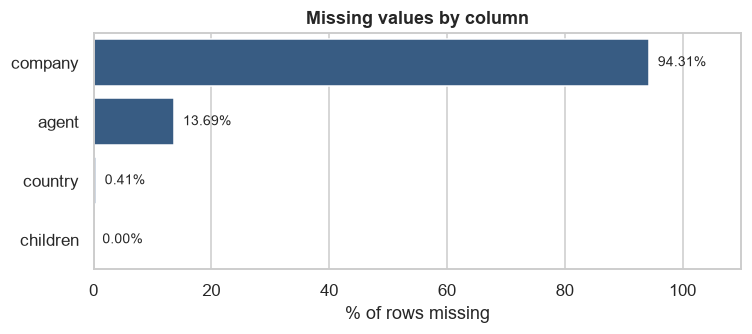

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.barplot(x=missing["missing_%"], y=missing.index, color=PRIMARY, ax=ax)
for i, v in enumerate(missing["missing_%"]):
    ax.text(v + 1.5, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set_xlim(0, 110)
ax.set_xlabel("% of rows missing")
ax.set_ylabel("")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()

**Reading — and why "just impute the median" would be wrong here.**
Only four columns have missing values, and each one means something different:

* **`company` — 112,593 missing (94.3%).** A missing company is not an *unknown* company: it means the
  booking was **not** paid for by a company. That is information, not absence. Dropping the column
  throws it away; median-imputing an ID number is meaningless. We keep it as a **binary flag**.
* **`agent` — 16,340 missing (13.7%).** Same logic: no agent ID means the guest booked **without** a
  travel agent. We turn `NaN` into an explicit `"None"` category.
* **`country` — 488 missing (0.41%).** Genuinely unknown. Filling with the mode (`PRT`) would invent
  hundreds of extra Portuguese guests, so we use an explicit `"Unknown"` category instead.
* **`children` — 4 missing (0.003%).** Four rows out of 119,390. Filling with `0` (the value in 92.7%
  of rows) is safe and cannot bias anything at that scale.

In [16]:
# 5.2 Duplicate rows.
n_dupes = int(df.duplicated().sum())
print(f"all 32 columns identical : {n_dupes:,}  ({n_dupes / len(df):.1%} of the dataset)")
print(f"distinct rows            : {len(df) - n_dupes:,}")

# The same count once the two leakage columns are removed. It is larger, because two
# otherwise identical bookings can carry different reservation_status_date values.
without_leakage = df.drop(columns=["reservation_status", "reservation_status_date"])
n_dupes_nl = int(without_leakage.duplicated().sum())
print()
print(f"identical on the 30 non-leakage columns : {n_dupes_nl:,}  ({n_dupes_nl / len(df):.1%})")
print(f"extra duplicates exposed by the drop    : {n_dupes_nl - n_dupes:,}")

all 32 columns identical : 31,994  (26.8% of the dataset)
distinct rows            : 87,396

identical on the 30 non-leakage columns : 32,252  (27.0%)
extra duplicates exposed by the drop    : 258


In [17]:
# What does a duplicated booking actually look like?
dupe_mask = df.duplicated(keep=False)
first = df[dupe_mask].iloc[0]
example = df[(df["hotel"] == first["hotel"]) &
             (df["lead_time"] == first["lead_time"]) &
             (df["arrival_date_day_of_month"] == first["arrival_date_day_of_month"]) &
             (df["adr"] == first["adr"])]
example[["hotel", TARGET, "lead_time", "arrival_date_month", "arrival_date_day_of_month",
         "adults", "market_segment", "customer_type", "adr", "reservation_status"]]

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,adults,market_segment,customer_type,adr,reservation_status
4,Resort Hotel,0,14,July,1,2,Online TA,Transient,98.0,Check-Out
5,Resort Hotel,0,14,July,1,2,Online TA,Transient,98.0,Check-Out


In [18]:
# Do repeated rows behave differently from rows that appear only once?
pd.DataFrame({
    "rows": [int(dupe_mask.sum()), int((~dupe_mask).sum())],
    "cancellation_rate": [df.loc[dupe_mask, TARGET].mean().round(4),
                          df.loc[~dupe_mask, TARGET].mean().round(4)],
}, index=["appears more than once", "appears exactly once"])

,rows,cancellation_rate
appears more than once,40165,0.5839
appears exactly once,79225,0.2622


**Decision: remove the duplicate bookings (~32,250 rows, 27% of the dataset).**

The rows are probably *genuine* separate bookings — a party booking four identical rooms on the same day
produces four identical rows, and the dataset carries no booking ID to tell them apart. So this is not a
recording fault.

But we are building a **classifier**, and that changes the calculus. Identical rows split across a
train/test boundary let a model memorise a row in training and be rewarded for "predicting" its twin in
the test set. That inflates every score we report without any real predictive skill. Since we cannot
distinguish real repeats from recording repeats, the conservative choice — the one that cannot flatter
our results — is to keep one copy of each distinct booking. All five published notebooks we compared
against make the same call.

Note the two counts above. 31,994 rows are identical across all 32 columns; 32,252 are identical once
`reservation_status` and `reservation_status_date` are dropped. The extra 258 are the same booking
recorded twice with different status dates — still indistinguishable to a model that never sees those
two columns. Deduplication is therefore the **last** step of section 9, run on the columns exactly as
the model will finally see them: dropping the leakage columns and merging `Undefined` → `SC` / `Unknown`
each expose duplicates that were hidden before.

*Cost of the decision:* group bookings become under-weighted, and the measured cancellation rate falls
from 37.0% to 27.3%, because repeated rows are disproportionately **non**-cancelled. We therefore report
**27.3% as the modelling baseline** and **37.0% as the business baseline**, and say which is which every
time either number appears.

In [19]:
# 5.3 Impossible / suspicious rows.
guests = df["adults"] + df["children"].fillna(0) + df["babies"]
nights = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

checks = pd.DataFrame([
    ("zero guests (adults + children + babies = 0)",        int((guests == 0).sum())),
    ("negative average daily rate (adr < 0)",               int((df["adr"] < 0).sum())),
    ("adr exactly 0 (complimentary / staff / group rate)",  int((df["adr"] == 0).sum())),
    ("adr above 1000 (extreme)",                            int((df["adr"] > 1000).sum())),
    ("meal = 'Undefined' (documented as SC, no meal)",      int((df["meal"] == "Undefined").sum())),
    ("market_segment = 'Undefined'",                        int((df["market_segment"] == "Undefined").sum())),
    ("distribution_channel = 'Undefined'",                  int((df["distribution_channel"] == "Undefined").sum())),
    ("adults > 10 (implausible party size)",                int((df["adults"] > 10).sum())),
    ("babies > 5 (implausible)",                            int((df["babies"] > 5).sum())),
    ("zero total nights booked",                            int((nights == 0).sum())),
], columns=["check", "rows"])
checks

,check,rows
0,zero guests (adults + children + babies = 0),180
1,negative average daily rate (adr < 0),1
2,adr exactly 0 (complimentary / staff / group r...,1959
3,adr above 1000 (extreme),1
4,"meal = 'Undefined' (documented as SC, no meal)",1169
5,market_segment = 'Undefined',2
6,distribution_channel = 'Undefined',5
7,adults > 10 (implausible party size),12
8,babies > 5 (implausible),2
9,zero total nights booked,715


In [20]:
# The extreme adr rows, up close.
df.nlargest(5, "adr")[["hotel", TARGET, "lead_time", "adults", "children",
                       "stays_in_weekend_nights", "stays_in_week_nights",
                       "market_segment", "customer_type", "adr", "reservation_status"]]

,hotel,is_canceled,lead_time,adults,children,stays_in_weekend_nights,stays_in_week_nights,market_segment,customer_type,adr,reservation_status
48515,City Hotel,1,35,2,0.0,0,1,Offline TA/TO,Transient,5400.0,Canceled
111403,City Hotel,0,0,1,0.0,0,1,Offline TA/TO,Transient,510.0,Check-Out
15083,Resort Hotel,0,1,2,0.0,0,1,Corporate,Transient,508.0,Check-Out
103912,City Hotel,0,81,2,2.0,1,1,Direct,Transient-Party,451.5,Check-Out
13142,Resort Hotel,1,378,2,0.0,4,10,Online TA,Transient,450.0,Canceled


**Reading.** One booking has `adr = 5400` for a single night in a City Hotel — the next highest rate
anywhere in the dataset is 510. That is a data-entry error, not a luxury suite. One booking has
`adr = -6.38`, which is impossible for an average daily rate. Both are removed as **demonstrable
errors**. The 1,959 rows with `adr = 0` are *not* errors — they are complimentary, staff and
group-contract rates — so they stay.

`meal = "Undefined"` and `meal = "SC"` are documented by the dataset authors as the same thing (no meal
package), so they are merged rather than dropped.

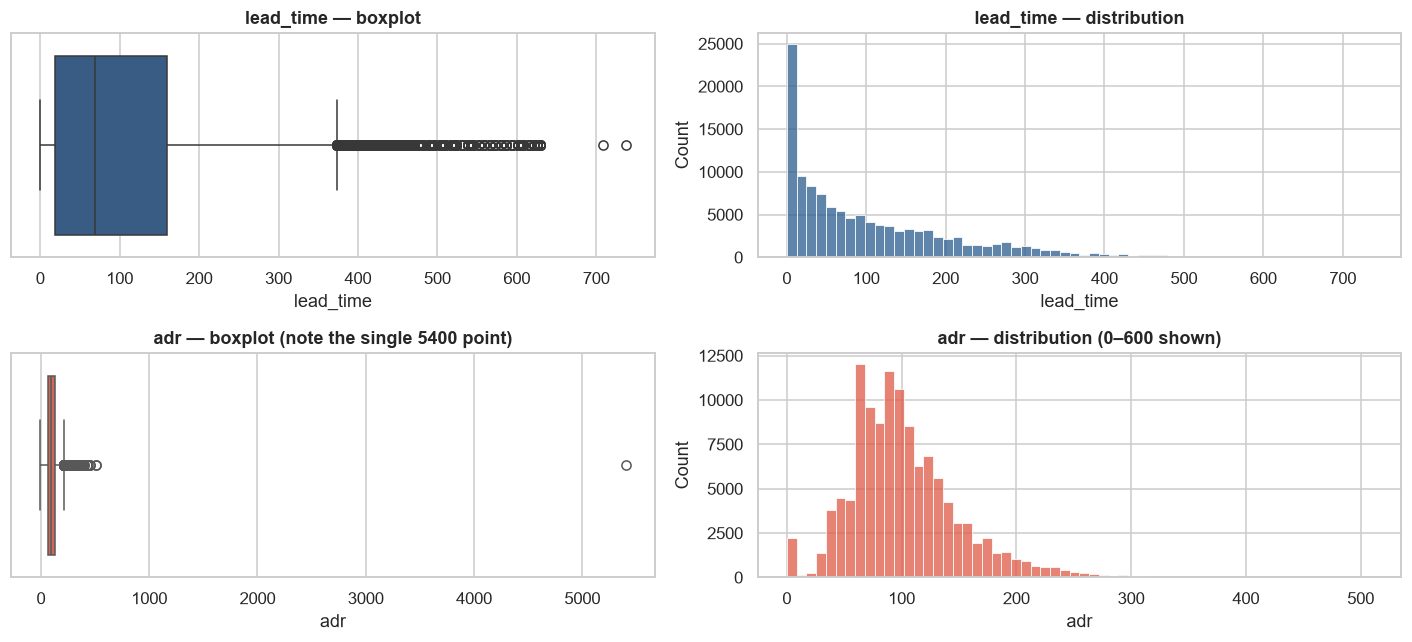

In [21]:
# 5.4 Outliers in the two continuous columns.
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

sns.boxplot(x=df["lead_time"], color=PRIMARY, ax=axes[0, 0])
axes[0, 0].set_title("lead_time — boxplot")
sns.histplot(df["lead_time"], bins=60, color=PRIMARY, ax=axes[0, 1])
axes[0, 1].set_title("lead_time — distribution")

sns.boxplot(x=df["adr"], color=ACCENT, ax=axes[1, 0])
axes[1, 0].set_title("adr — boxplot (note the single 5400 point)")
sns.histplot(df.loc[df["adr"].between(0, 600), "adr"], bins=60, color=ACCENT, ax=axes[1, 1])
axes[1, 1].set_title("adr — distribution (0–600 shown)")

plt.tight_layout()
plt.show()

In [22]:
# How many points does the classic 1.5 x IQR rule flag?
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lo, hi, int(((s < lo) | (s > hi)).sum())

for col in ["lead_time", "adr", "stays_in_week_nights", "previous_cancellations"]:
    lo, hi, n = iqr_outliers(df[col])
    print(f"{col:<28} fence = [{lo:8.2f}, {hi:8.2f}]   flagged = {n:6,}  ({n / len(df):.2%})")

lead_time                    fence = [ -195.00,   373.00]   flagged =  3,005  (2.52%)
adr                          fence = [  -15.77,   211.06]   flagged =  3,793  (3.18%)
stays_in_week_nights         fence = [   -2.00,     6.00]   flagged =  3,354  (2.81%)
previous_cancellations       fence = [    0.00,     0.00]   flagged =  6,484  (5.43%)


**Reading.** The IQR rule flags thousands of `lead_time` values, but a booking made 400 days ahead is a
perfectly real booking — and section 8.2 shows it is exactly the kind that gets cancelled. Deleting
those rows would delete the strongest signal in the dataset.

**Decision:** no blanket outlier removal. We remove only the two demonstrable errors identified above
(`adr < 0`, and the single `adr = 5400`). Heavy tails are handled where they belong — in the modelling
pipeline, by scaling for the linear model, and not at all for the tree models, which are invariant to
monotone transformations of a feature.

---
## 6. The target — and why accuracy is a trap

Before any driver analysis: how balanced is `is_canceled`?

In [23]:
counts = df[TARGET].value_counts().sort_index()
shares = df[TARGET].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({"bookings": counts, "share_%": shares.round(2)}).rename(
    index={0: "0 = not cancelled", 1: "1 = cancelled / no-show"}
)

,bookings,share_%
is_canceled,,
0 = not cancelled,75166,62.96
1 = cancelled / no-show,44224,37.04


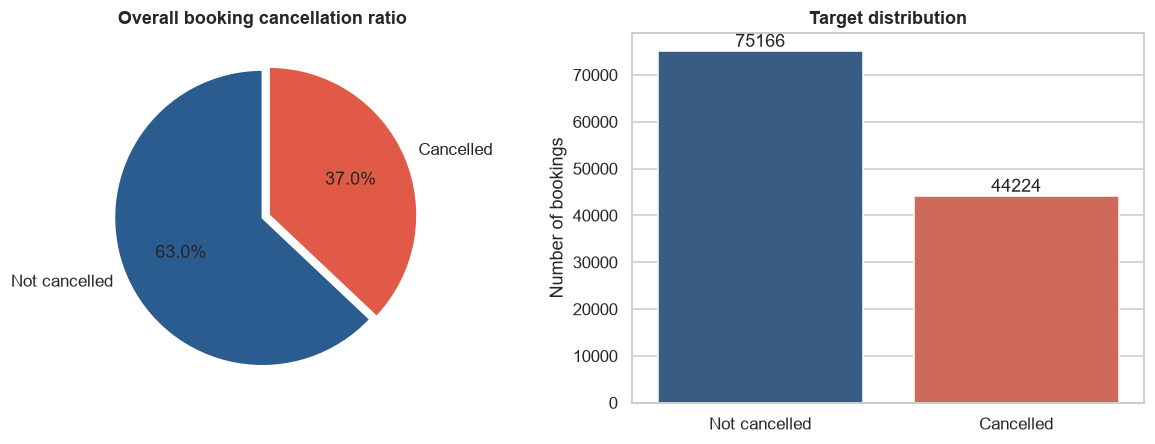

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].pie(counts, labels=["Not cancelled", "Cancelled"], autopct="%1.1f%%",
            colors=PALETTE, startangle=90, explode=(0, 0.05))
axes[0].set_title("Overall booking cancellation ratio")

sns.countplot(x=TARGET, data=df, hue=TARGET, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Not cancelled", "Cancelled"])
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of bookings")
axes[1].set_title("Target distribution")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%d")

plt.tight_layout()
plt.show()

**Reading.** 37.0% of bookings are cancelled. The classes are imbalanced, but not severely — so SMOTE is
not needed; stratification, class weights and a tuned decision threshold are enough.

The number that matters for the report: **a model that predicts "never cancels" for every booking scores
63.0% accuracy** and is useless to the manager, because it never flags a single at-risk booking. That is
why the plan makes **PR-AUC, F1 and recall on the cancelled class** the primary metrics, and treats
accuracy as a secondary number that is reported but never used to choose a model.

---
## 7. Leakage check — which columns must never become features

This is the section where our pipeline differs from most published notebooks on this dataset. A feature
that looks *too good* is usually a feature that already knows the answer.

In [25]:
# 7.1 reservation_status against the target.
pd.crosstab(df["reservation_status"], df[TARGET], margins=True)

is_canceled,0,1,All
reservation_status,,,
Canceled,0,43017,43017
Check-Out,75166,0,75166
No-Show,0,1207,1207
All,75166,44224,119390


**Reading.** The mapping is perfect and deterministic: `Check-Out` → always 0; `Canceled` and `No-Show`
→ always 1. `reservation_status` **is** the target written in words, and `reservation_status_date` is
the date that outcome was recorded. Any model given these columns scores ~100% and has learned nothing.
Both are **dropped permanently**.

In [26]:
# 7.2 Automatic scan: does any column value predict the target almost perfectly?
def perfect_predictor_scan(frame, min_support=500):
    rows = []
    for col in frame.columns:
        if col == TARGET:
            continue
        s = frame[col]
        if s.nunique() > 30:
            if pd.api.types.is_numeric_dtype(s):
                s = s > 0                      # collapse counts to a yes/no flag
            else:
                continue
        g = frame.groupby(s, observed=True)[TARGET].agg(["count", "mean"])
        g = g[g["count"] >= min_support]
        for value, row in g.iterrows():
            if row["mean"] < 0.02 or row["mean"] > 0.98:
                rows.append((col, str(value), int(row["count"]), round(row["mean"], 4)))
    return pd.DataFrame(rows, columns=["column", "value", "support", "cancellation_rate"])

perfect_predictor_scan(df).sort_values("support", ascending=False)

,column,value,support,cancellation_rate
3,reservation_status,Check-Out,75166,0.0000
2,reservation_status,Canceled,43017,1.0000
0,deposit_type,Non Refund,14587,0.9936
1,required_car_parking_spaces,1,7383,0.0000
4,reservation_status,No-Show,1207,1.0000


Three things are flagged — and they are **not** all the same problem. Telling them apart is the whole
point of this section.

In [27]:
# 7.3 The parking-space column, up close.
parking = pd.crosstab(df["required_car_parking_spaces"] > 0, df[TARGET])
parking.index = ["no parking requested", "parking requested"]
parking["cancellation_rate"] = (parking[1] / parking.sum(axis=1)).round(4)
parking

is_canceled,0,1,cancellation_rate
no parking requested,67750,44224,0.3949
parking requested,7416,0,0.0000


**7,416 bookings request a parking space, and not one of them was ever cancelled.** A perfect separation
across 7,416 rows is not a behavioural insight — it is a timing artefact. The field is populated when
the guest actually arrives and asks for a space, which is *after* the cancellation decision has already
been made. Feeding it to the model would leak the future.

**Decision (Week 2, on EDA evidence):** `required_car_parking_spaces` joins the post-booking exclusion
list, alongside `assigned_room_type` (set at check-in), `booking_changes` (amendments made after the
booking) and `days_in_waiting_list` (accrues after the booking). They stay in the cleaned file so that a
clearly labelled sensitivity analysis can quantify what they would add — they simply do not enter the
main model.

In [28]:
# 7.4 deposit_type — a genuine finding that looks like leakage but is not.
deposit = df.groupby("deposit_type", observed=True)[TARGET].agg(["count", "mean"])
deposit.columns = ["bookings", "cancellation_rate"]
deposit["cancellation_rate"] = deposit["cancellation_rate"].round(4)
deposit.sort_values("cancellation_rate", ascending=False)

,bookings,cancellation_rate
deposit_type,,
Non Refund,14587,0.9936
No Deposit,104641,0.2838
Refundable,162,0.2222


**Reading.** 99.36% of `Non Refund` bookings are cancelled — the *opposite* of what common sense
predicts, since a guest who has already paid a non-refundable deposit has every incentive to turn up.

This is **not** leakage: `deposit_type` is fixed at the moment of booking, so it is genuinely available
at prediction time. The most plausible explanation, consistent with the published literature on this
dataset, is that the hotels imposed non-refundable terms on bookings they already judged risky (mainly
`Groups` and long-lead `Offline TA/TO`), and those bookings were then simply never honoured.

`deposit_type` therefore **stays a feature** — but the report must state plainly that the model is
partly learning the hotel's own historical risk policy rather than pure guest behaviour, and that the
relationship would break if the deposit policy changed.

---
## 8. EDA — what actually drives a cancellation?

Every chart below is read the same way: *how does the cancellation rate change across the levels of this
variable, and is the group big enough to trust?* Rates in this section are computed on the **raw**
119,390 rows, so they are the **business** baseline (37.0%). Section 9 removes duplicates, after which
the **modelling** baseline is 27.3%.

In [29]:
# A readable label for the target, used as the hue in every chart below.
df["outcome"] = df[TARGET].map({0: "Not cancelled", 1: "Cancelled"})
OUTCOME_ORDER = ["Not cancelled", "Cancelled"]

# A small helper so every "rate by category" chart in this section is drawn the same way.
def rate_by(col, ax, order=None, rotate=0, min_support=0):
    g = df.groupby(col, observed=True)[TARGET].agg(["count", "mean"])
    g = g[g["count"] >= min_support]
    if order is not None:
        g = g.reindex([o for o in order if o in g.index])
    else:
        g = g.sort_values("mean")
    bars = ax.bar(g.index.astype(str), g["mean"] * 100, color=PRIMARY)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
    ax.axhline(df[TARGET].mean() * 100, color=ACCENT, ls="--", lw=1.2,
               label=f"overall {df[TARGET].mean() * 100:.1f}%")
    ax.set_ylabel("Cancellation rate (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", labelrotation=rotate)
    return g

print("helper ready")

helper ready


### 8.1 Hotel type

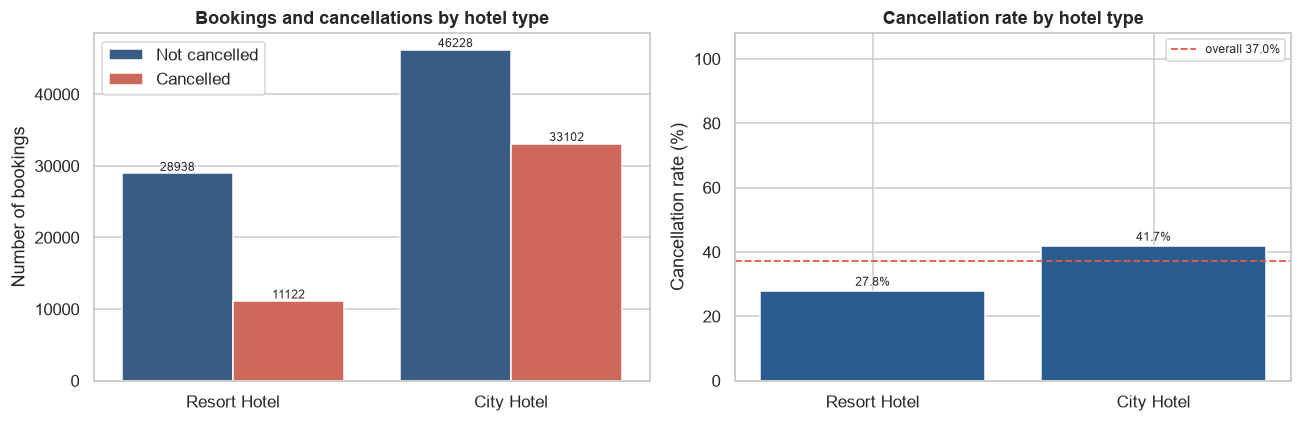

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="hotel", hue="outcome", hue_order=OUTCOME_ORDER,
                palette=PALETTE, ax=axes[0])
axes[0].set_title("Bookings and cancellations by hotel type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of bookings")
axes[0].legend(title="")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d", fontsize=8)

rate_by("hotel", axes[1])
axes[1].set_title("Cancellation rate by hotel type")

plt.tight_layout()
plt.show()

**Reading.** The City Hotel takes twice the volume (79,330 vs 40,060) *and* cancels at a much higher
rate: **41.7% vs 27.8%**. The gap is large enough that `hotel` is a real feature, but not so large that
the two hotels need separate models — we keep the joint model with `hotel` as a feature, which was the
default in the plan, and note it as a limitation the team can revisit.

### 8.2 Lead time — the single strongest booking-time signal

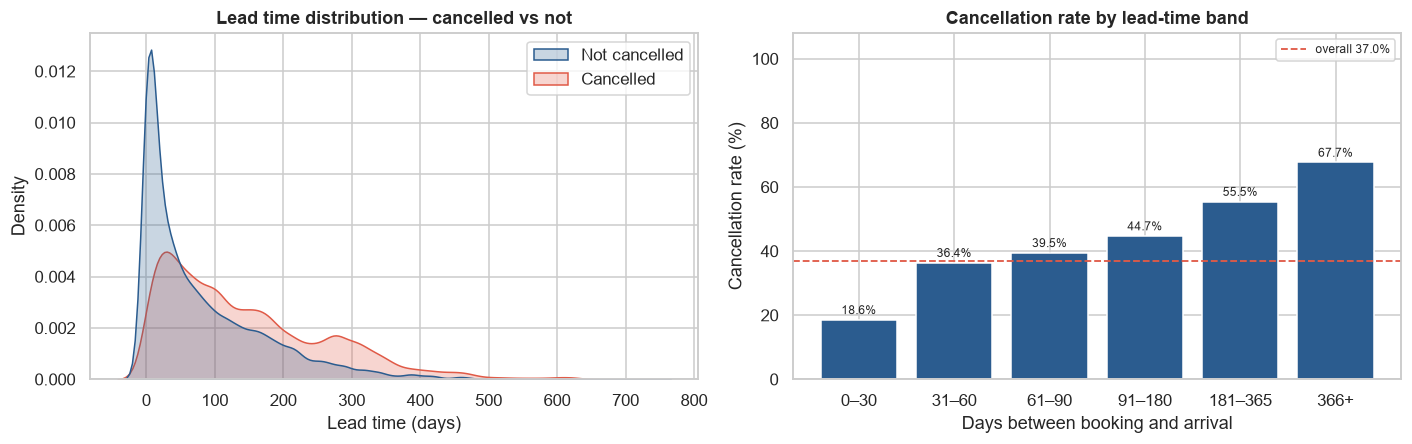

,bookings,cancellation_rate
lead_time_group,,
0–30,38706,0.1856
31–60,16970,0.3638
61–90,12583,0.3947
91–180,26439,0.4471
181–365,21544,0.5545
366+,3148,0.6766


In [31]:
LEAD_BINS = [-1, 30, 60, 90, 180, 365, 10_000]
LEAD_LABELS = ["0–30", "31–60", "61–90", "91–180", "181–365", "366+"]
df["lead_time_group"] = pd.cut(df["lead_time"], bins=LEAD_BINS, labels=LEAD_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.kdeplot(data=df, x="lead_time", hue="outcome", hue_order=OUTCOME_ORDER,
            palette=PALETTE, fill=True, common_norm=False, ax=axes[0])
axes[0].set_title("Lead time distribution — cancelled vs not")
axes[0].set_xlabel("Lead time (days)")
axes[0].legend_.set_title("")

lead_tbl = rate_by("lead_time_group", axes[1], order=LEAD_LABELS)
axes[1].set_title("Cancellation rate by lead-time band")
axes[1].set_xlabel("Days between booking and arrival")

plt.tight_layout()
plt.show()

lead_tbl.rename(columns={"count": "bookings", "mean": "cancellation_rate"}).round(4)

In [32]:
# Median lead time, cancelled vs not.
df.groupby(TARGET)["lead_time"].agg(["count", "mean", "median", "min", "max"]).round(1)

,count,mean,median,min,max
is_canceled,,,,,
0,75166,80.0,45.0,0,737
1,44224,144.8,113.0,0,629


**Reading.** This is the clearest monotone relationship in the dataset. Risk climbs from **18.6%** for
bookings made within a month of arrival to **67.7%** for bookings made more than a year ahead — a
3.6× spread. The median cancelled booking was made **113 days** ahead; the median honoured booking only
**45 days** ahead.

`lead_time` is known at booking time, is available for every row and has no missing values, so it is the
backbone of the feature set. The banded version (`lead_time_group`) is kept alongside the raw number
because it is what the manager will actually act on ("re-confirm anything booked more than six months
out").

### 8.3 Deposit type and customer type

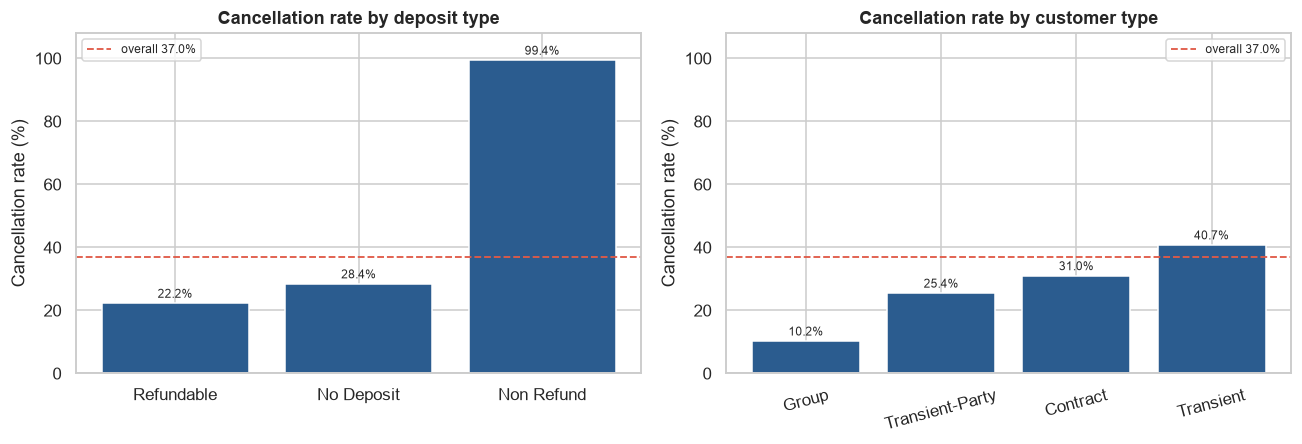

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
rate_by("deposit_type", axes[0])
axes[0].set_title("Cancellation rate by deposit type")
rate_by("customer_type", axes[1], rotate=15)
axes[1].set_title("Cancellation rate by customer type")
plt.tight_layout()
plt.show()

**Reading.** `Non Refund` at **99.4%** is discussed in section 7.4 — it is a real booking-time feature
that encodes the hotel's own historical risk policy. Among customer types, `Transient` (individual
bookings not part of a group or contract) cancels most at **40.8%**, `Transient-Party` sits at 25.4% and
`Contract` at 31.0%; `Group` is lowest at 10.2% but holds only 577 bookings, so that rate is thin.
`customer_type` is a useful but secondary feature.

### 8.4 Where the booking came from

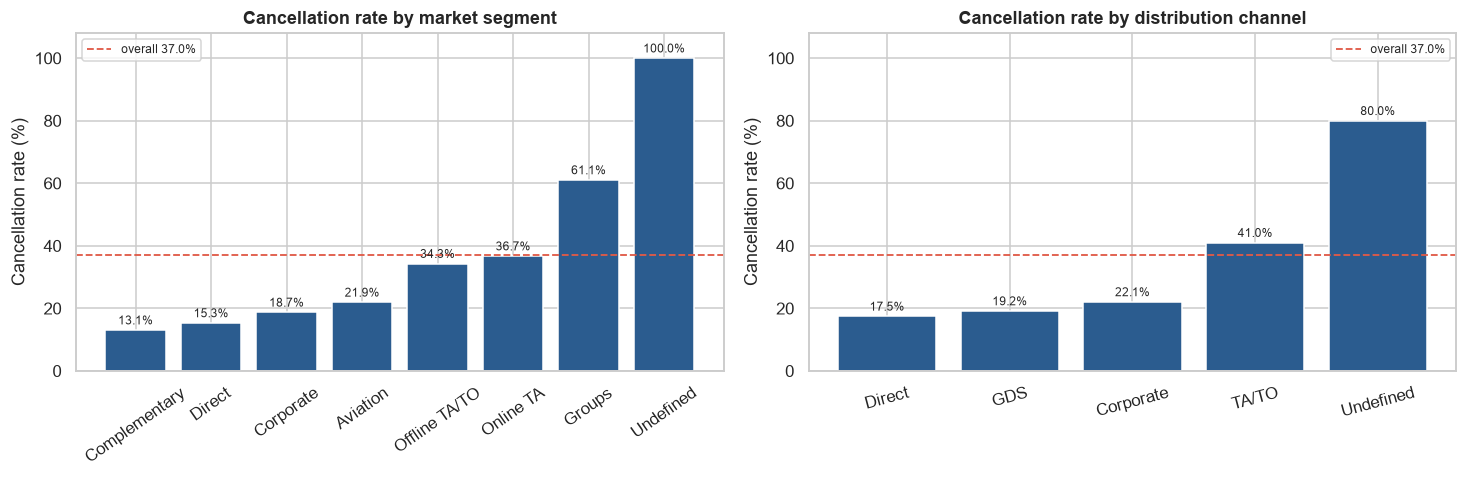

,bookings,cancellation_rate
market_segment,,
Undefined,2,1.0000
Groups,19811,0.6106
Online TA,56477,0.3672
Offline TA/TO,24219,0.3432
Aviation,237,0.2194
Corporate,5295,0.1873
Direct,12606,0.1534
Complementary,743,0.1306


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
rate_by("market_segment", axes[0], rotate=35)
axes[0].set_title("Cancellation rate by market segment")
rate_by("distribution_channel", axes[1], rotate=15)
axes[1].set_title("Cancellation rate by distribution channel")
plt.tight_layout()
plt.show()

df.groupby("market_segment", observed=True)[TARGET].agg(
    bookings="count", cancellation_rate="mean").sort_values("cancellation_rate", ascending=False).round(4)

**Reading.** `Groups` cancel at **61.1%** against **15.3%** for `Direct` bookings — a four-fold
difference, and both segments are large enough (19,811 and 12,606 bookings) to trust. This is the
second-strongest driver after lead time and it is exactly the kind of finding a revenue manager can act
on: group allocations need firmer terms or an overbooking buffer, direct bookings need neither.

`Undefined` holds only two bookings, so it is merged into `Unknown` during cleaning rather than being
treated as a real segment.

### 8.5 Guest history

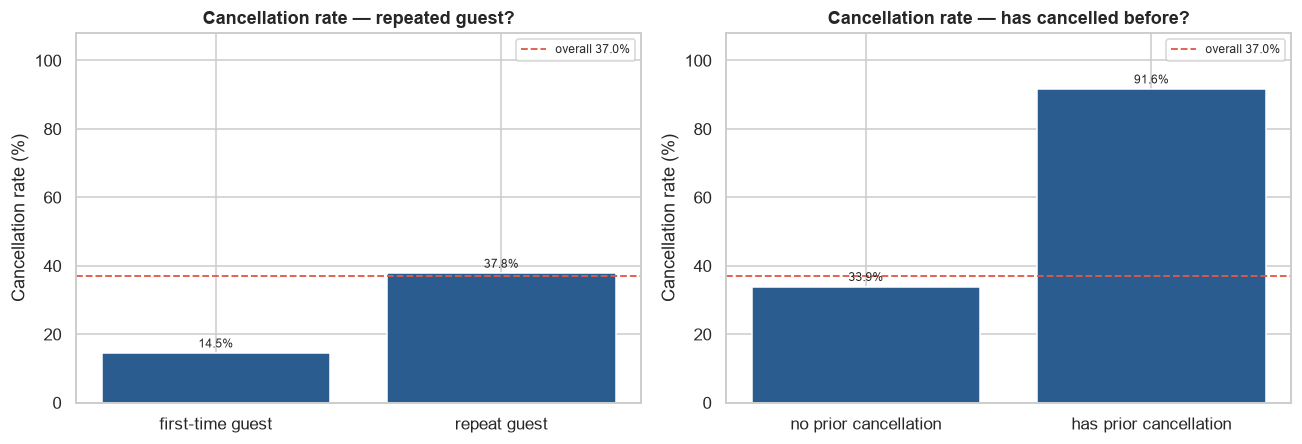

,bookings,cancellation_rate
has_previous_cancellation,,
0,112906,0.3391
1,6484,0.9164


In [35]:
df["has_previous_cancellation"] = (df["previous_cancellations"] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
rate_by("is_repeated_guest", axes[0])
axes[0].set_title("Cancellation rate — repeated guest?")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["first-time guest", "repeat guest"])
rate_by("has_previous_cancellation", axes[1])
axes[1].set_title("Cancellation rate — has cancelled before?")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["no prior cancellation", "has prior cancellation"])
plt.tight_layout()
plt.show()

df.groupby("has_previous_cancellation")[TARGET].agg(
    bookings="count", cancellation_rate="mean").round(4)

**Reading.** Guests with at least one previous cancellation cancel again **91.6%** of the time, against
**33.9%** for everyone else, across 6,484 bookings. Past behaviour is the best single predictor of
future behaviour — as it usually is.

Repeat guests cancel far less often than first-timers. Both signals are known at booking time and both
survive into the feature set.

**Fairness note for the report:** `previous_cancellations` is a *customer history* variable. Using it to
set stricter terms for individuals is a policy decision, not a modelling one, and section 10 of the plan
commits us to flag it as such rather than let the model quietly drive customer treatment.

### 8.6 Special requests

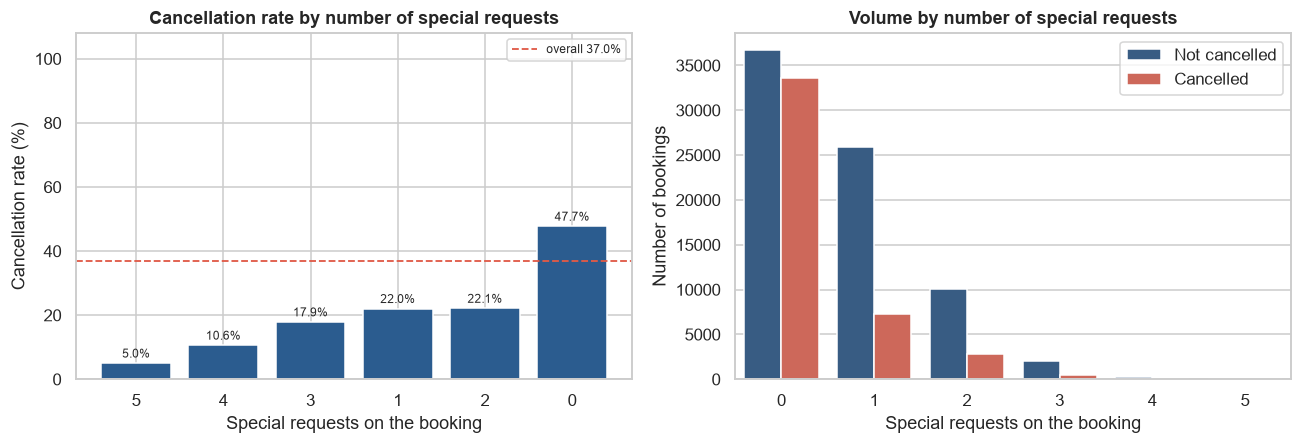

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
rate_by("total_of_special_requests", axes[0])
axes[0].set_title("Cancellation rate by number of special requests")
axes[0].set_xlabel("Special requests on the booking")

sns.countplot(data=df, x="total_of_special_requests", hue="outcome",
              hue_order=OUTCOME_ORDER, palette=PALETTE, ax=axes[1])
axes[1].set_title("Volume by number of special requests")
axes[1].set_xlabel("Special requests on the booking")
axes[1].set_ylabel("Number of bookings")
axes[1].legend(title="", labels=["Not cancelled", "Cancelled"])
plt.tight_layout()
plt.show()

**Reading.** Cancellation risk falls sharply as soon as the guest asks for anything: **47.7%** with no
special request, **22.0%** with a single one, and down to **10.6%** at four. The interpretation is
intuitive — a guest who has asked for a high floor and a late check-in has already invested in the stay.
The 70,318 bookings with zero requests are more than half the dataset, so this is a large, reliable
split. Unlike parking, special requests are made **at booking time**, so this is a legitimate feature.

### 8.7 Seasonality and trend

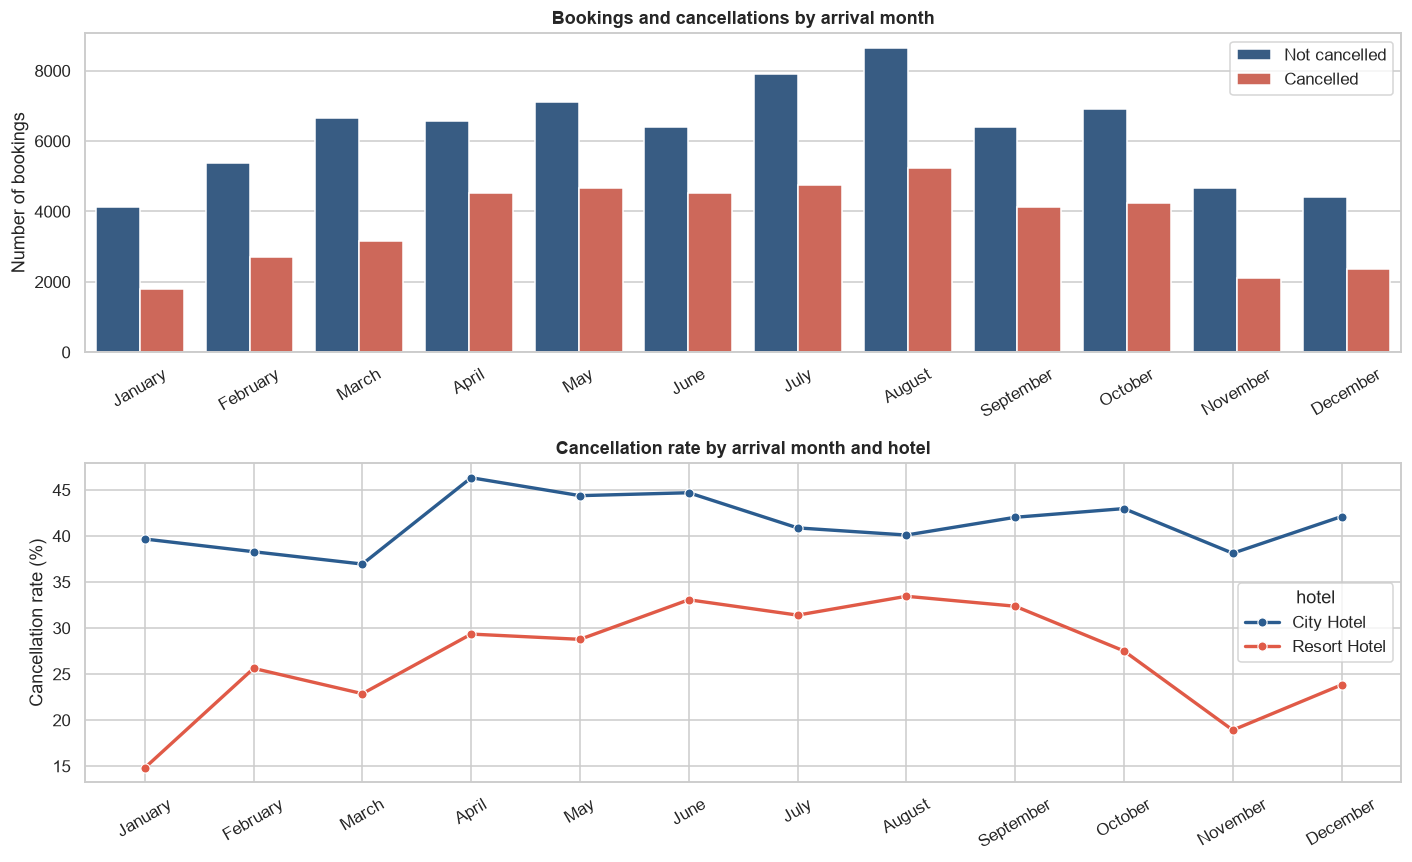

In [37]:
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],
                                          categories=MONTH_ORDER, ordered=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

sns.countplot(data=df, x="arrival_date_month", hue="outcome", hue_order=OUTCOME_ORDER,
              palette=PALETTE, ax=axes[0])
axes[0].set_title("Bookings and cancellations by arrival month")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of bookings")
axes[0].legend(title="")
axes[0].tick_params(axis="x", labelrotation=30)

monthly = (df.groupby(["arrival_date_month", "hotel"], observed=True)[TARGET]
             .mean().mul(100).reset_index())
sns.lineplot(data=monthly, x="arrival_date_month", y=TARGET, hue="hotel",
             marker="o", linewidth=2.2, palette=PALETTE, ax=axes[1])
axes[1].set_title("Cancellation rate by arrival month and hotel")
axes[1].set_ylabel("Cancellation rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()

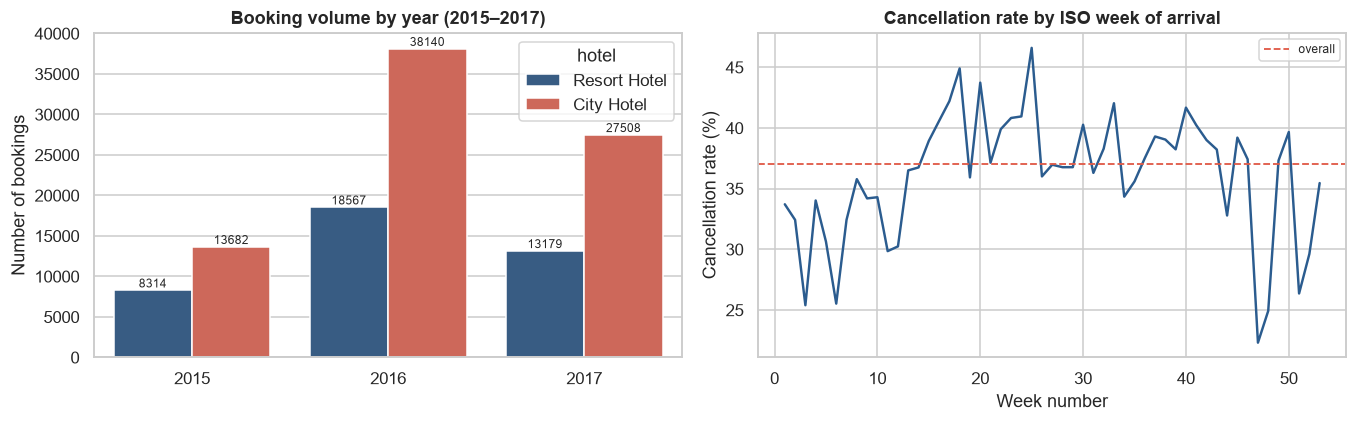

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

sns.countplot(data=df, x="arrival_date_year", hue="hotel", palette=PALETTE, ax=axes[0])
axes[0].set_title("Booking volume by year (2015–2017)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of bookings")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d", fontsize=8)

weekly = df.groupby("arrival_date_week_number", observed=True)[TARGET].mean().mul(100)
axes[1].plot(weekly.index, weekly.values, color=PRIMARY, lw=1.6)
axes[1].axhline(df[TARGET].mean() * 100, color=ACCENT, ls="--", lw=1.2, label="overall")
axes[1].set_title("Cancellation rate by ISO week of arrival")
axes[1].set_xlabel("Week number")
axes[1].set_ylabel("Cancellation rate (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Reading.** Volume is strongly seasonal — August is the peak and January the trough — but the
*cancellation rate* is much flatter than the volume, wobbling in a fairly narrow band around the overall
average with no clean annual cycle. Season matters far less than lead time or market segment.

2015 and 2017 are **partial years** (the data starts in July 2015 and stops at the end of August 2017),
so `arrival_date_year` must never be read as a year-on-year trend. It is kept as a feature only because
the deposit policy visibly changed over the period; the report states the partial-year caveat.

### 8.8 Where guests come from

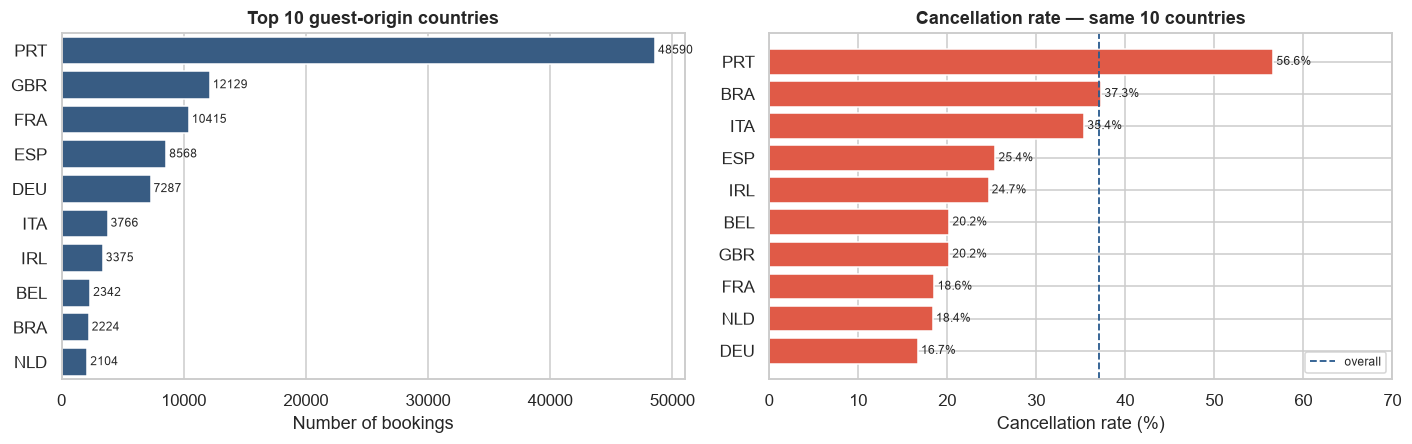

,bookings,rate
country,,
PRT,48590,0.5664
BRA,2224,0.3732
ITA,3766,0.3540
ESP,8568,0.2541
IRL,3375,0.2465
BEL,2342,0.2024
GBR,12129,0.2022
FRA,10415,0.1857
NLD,2104,0.1839


In [39]:
top10 = df["country"].value_counts().head(10)
top_rates = (df[df["country"].isin(top10.index)]
             .groupby("country", observed=True)[TARGET]
             .agg(bookings="count", rate="mean")
             .sort_values("rate", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.barplot(x=top10.values, y=top10.index, color=PRIMARY, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%d", fontsize=8, padding=2)
axes[0].set_title("Top 10 guest-origin countries")
axes[0].set_xlabel("Number of bookings")
axes[0].set_ylabel("")

bars = axes[1].barh(top_rates.index[::-1], top_rates["rate"][::-1] * 100, color=ACCENT)
axes[1].bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
axes[1].axvline(df[TARGET].mean() * 100, color=PRIMARY, ls="--", lw=1.2, label="overall")
axes[1].set_title("Cancellation rate — same 10 countries")
axes[1].set_xlabel("Cancellation rate (%)")
axes[1].set_xlim(0, 70)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

top_rates.round(4)

**Reading.** Portugal is both the largest source of bookings (48,590, 40.7%) **and** by far the most
likely to cancel (**56.6%**). Brazil (37.3%) and Italy (35.4%) sit around the overall average, and the
remaining seven of the top ten all fall below 26% — Germany is lowest at 16.7%. These are Portuguese
hotels, so this is really the *domestic vs international* split: domestic guests book cheaply, book
early and walk away easily.

`country` has 177 levels, so one-hot encoding it would add 176 columns — most of them near-empty. The
plan's decision holds: notebook 02 compares (a) a `domestic / other-top-10 / rest / Unknown` grouping
against (b) a leakage-safe target encoding fitted inside the CV folds, and keeps whichever performs
better without inflating the feature count.

### 8.9 Price (ADR)

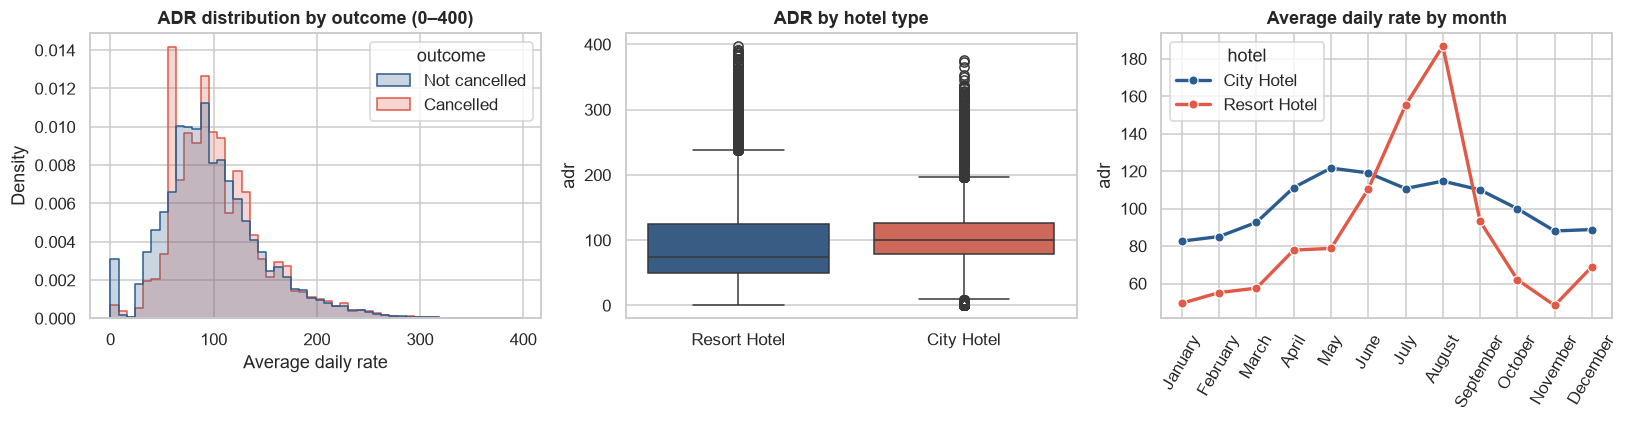

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df[df["adr"].between(0, 400)], x="adr", hue="outcome",
             hue_order=OUTCOME_ORDER, palette=PALETTE, bins=50, element="step",
             stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("ADR distribution by outcome (0–400)")
axes[0].set_xlabel("Average daily rate")

sns.boxplot(data=df[df["adr"].between(0, 400)], x="hotel", y="adr",
            hue="hotel", palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("ADR by hotel type")
axes[1].set_xlabel("")

monthly_adr = df.groupby(["arrival_date_month", "hotel"], observed=True)["adr"].mean().reset_index()
sns.lineplot(data=monthly_adr, x="arrival_date_month", y="adr", hue="hotel",
             marker="o", linewidth=2.2, palette=PALETTE, ax=axes[2])
axes[2].set_title("Average daily rate by month")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", labelrotation=60)

plt.tight_layout()
plt.show()

**Reading.** Cancelled bookings sit at slightly higher rates than honoured ones, but the two
distributions overlap almost completely — `adr` on its own separates the classes weakly. It is worth
keeping because it interacts with season and hotel type (the Resort Hotel's summer rates are three times
its winter rates, while the City Hotel is nearly flat), which the tree models can exploit.

### 8.10 Rooms, party size and length of stay

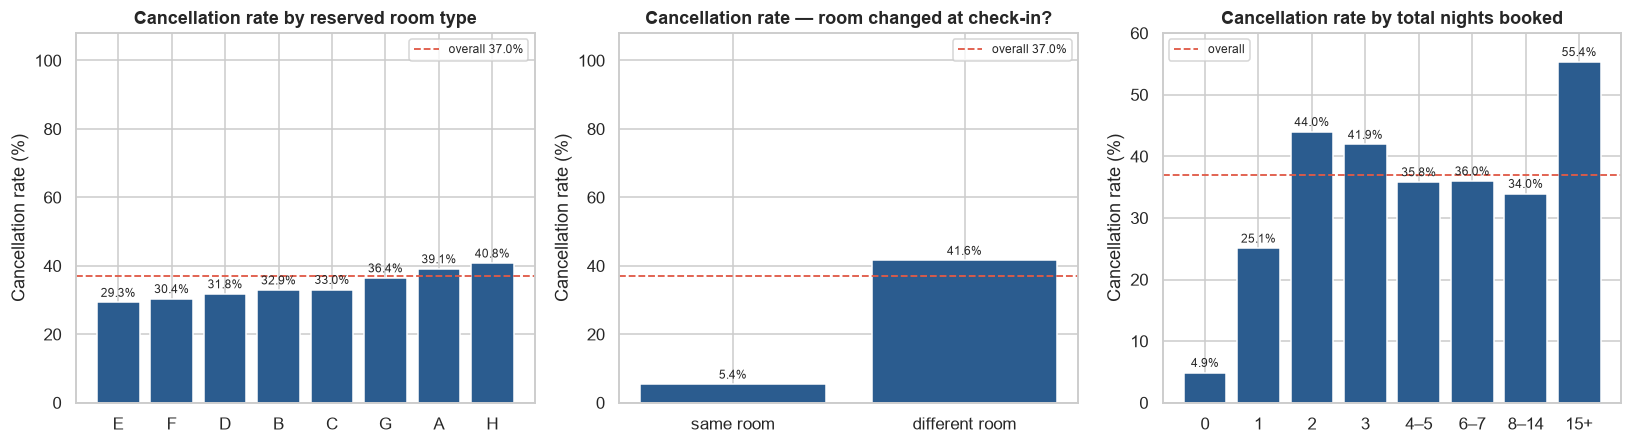

In [41]:
df["room_changed"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)
df["total_guests"] = df["adults"] + df["children"].fillna(0) + df["babies"]
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

rate_by("reserved_room_type", axes[0], min_support=200)
axes[0].set_title("Cancellation rate by reserved room type")

rate_by("room_changed", axes[1])
axes[1].set_title("Cancellation rate — room changed at check-in?")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["same room", "different room"])

nights_grp = pd.cut(df["total_nights"], bins=[-1, 0, 1, 2, 3, 5, 7, 14, 100],
                    labels=["0", "1", "2", "3", "4–5", "6–7", "8–14", "15+"])
g = df.groupby(nights_grp, observed=True)[TARGET].mean().mul(100)
bars = axes[2].bar(g.index.astype(str), g.values, color=PRIMARY)
axes[2].bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
axes[2].axhline(df[TARGET].mean() * 100, color=ACCENT, ls="--", lw=1.2, label="overall")
axes[2].set_title("Cancellation rate by total nights booked")
axes[2].set_ylabel("Cancellation rate (%)")
axes[2].set_ylim(0, 60)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Reading.** Room type shows a mild spread. The `room_changed` chart is the interesting one and it is
the mirror image of the parking finding: bookings that were given a **different** room than reserved
cancel at a *far lower* rate — because a room can only be re-assigned to a guest who actually turned up.
`room_changed` is therefore **post-booking**, not a booking-time feature. We compute it, label it, and
keep it out of the main model.

Length of stay has a mild hump in the middle of the range and is a weak signal on its own.

### 8.11 Correlation between the numeric columns

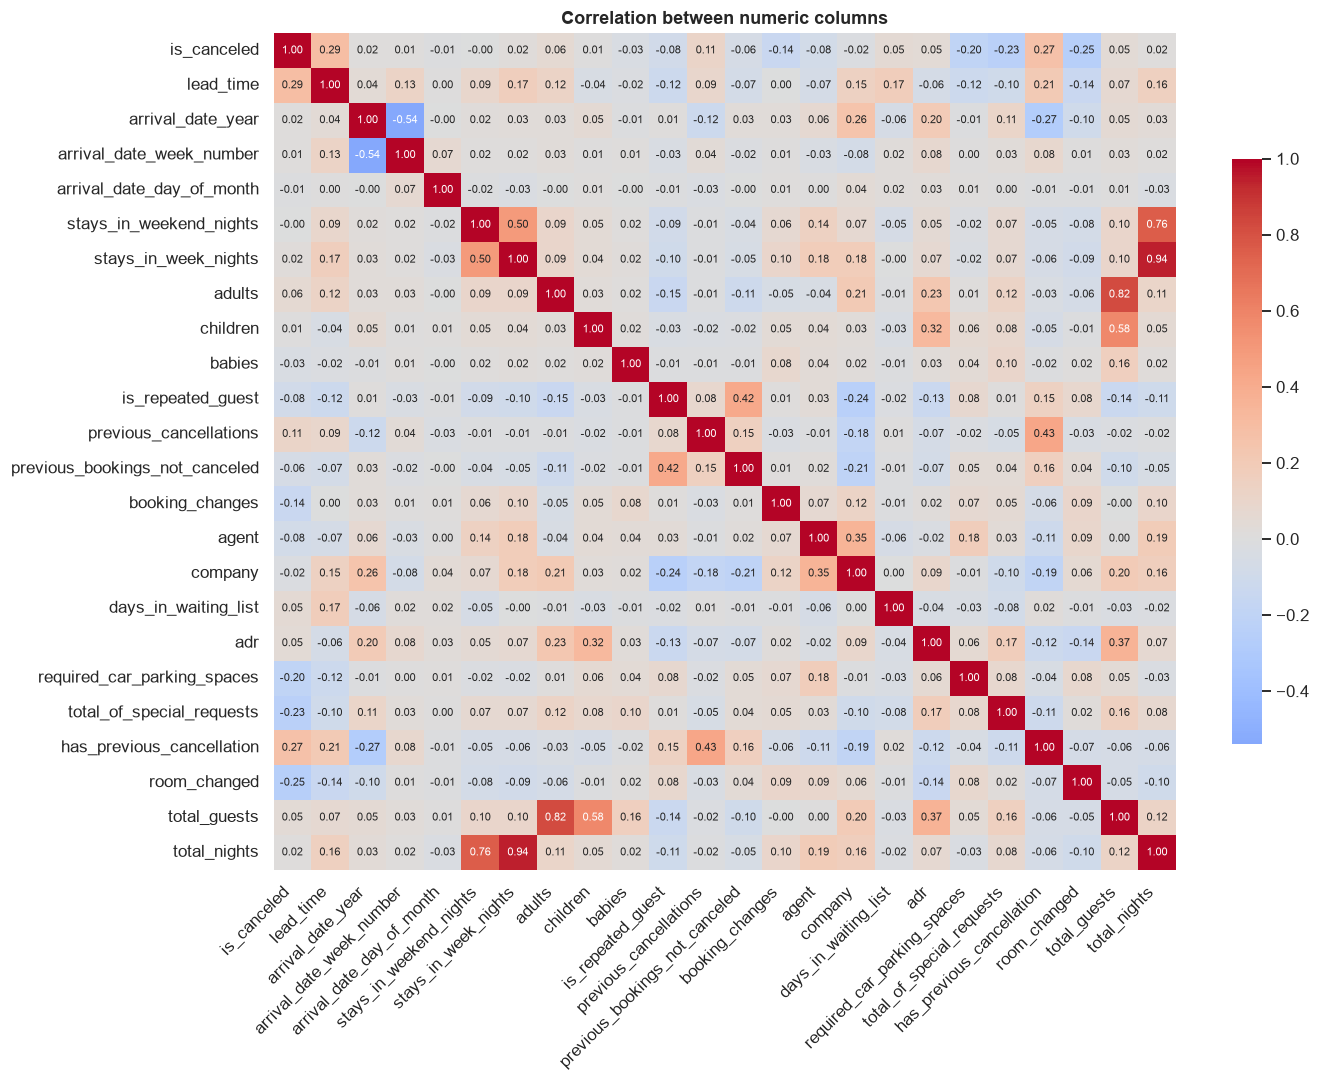

In [42]:
num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
plt.title("Correlation between numeric columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [43]:
# Linear correlation with the target, strongest first.
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3)

lead_time                         0.293
has_previous_cancellation         0.271
room_changed                     -0.248
total_of_special_requests        -0.235
required_car_parking_spaces      -0.195
booking_changes                  -0.144
previous_cancellations            0.110
is_repeated_guest                -0.085
agent                            -0.083
adults                            0.060
previous_bookings_not_canceled   -0.057
days_in_waiting_list              0.054
adr                               0.048
total_guests                      0.047
babies                           -0.032
stays_in_week_nights              0.025
company                          -0.021
total_nights                      0.018
arrival_date_year                 0.017
arrival_date_week_number          0.008
arrival_date_day_of_month        -0.006
children                          0.005
stays_in_weekend_nights          -0.002
Name: is_canceled, dtype: float64

**Reading.** Nothing in the numeric block correlates strongly with the target. The five largest are
`lead_time` (+0.29), `has_previous_cancellation` (+0.27), `room_changed` (−0.25),
`total_of_special_requests` (−0.23) and `required_car_parking_spaces` (−0.20) — and two of those five
are the post-booking columns section 7 already excluded. Among columns that survive into the model,
nothing exceeds |0.29|.

Collinearity worth flagging for the linear baseline, which is the only model that suffers from it:
`total_nights` correlates 0.94 with `stays_in_week_nights` and `total_guests` 0.82 with `adults` — by
construction, since each is a sum of the others. `arrival_date_year` and `arrival_date_week_number` sit
at −0.54 purely because 2015 and 2017 are partial years (2015 has no early weeks, 2017 no late ones).

The important conclusion for the model strategy: **the signal is not linear and not in any single
column.** Pearson correlation only sees straight lines, and the strongest drivers we found —
`deposit_type`, `market_segment`, `country` — are categorical and invisible here. This is the concrete
evidence for the plan's decision to compare a linear baseline (Logistic Regression) against tree
ensembles that can capture interactions, rather than assuming a linear model is enough.

### 8.12 EDA summary — every driver in one table

In [44]:
drivers = []
for col in ["hotel", "deposit_type", "market_segment", "distribution_channel",
            "customer_type", "lead_time_group", "is_repeated_guest",
            "has_previous_cancellation", "total_of_special_requests"]:
    g = df.groupby(col, observed=True)[TARGET].agg(["count", "mean"])
    g = g[g["count"] >= 200]
    drivers.append({
        "variable": col,
        "levels": len(g),
        "lowest_rate": f"{g['mean'].min():.1%} ({g['mean'].idxmin()})",
        "highest_rate": f"{g['mean'].max():.1%} ({g['mean'].idxmax()})",
        "spread_pp": round((g["mean"].max() - g["mean"].min()) * 100, 1),
    })

pd.DataFrame(drivers).sort_values("spread_pp", ascending=False).reset_index(drop=True)

,variable,levels,lowest_rate,highest_rate,spread_pp
0,deposit_type,2,28.4% (No Deposit),99.4% (Non Refund),71.0
1,has_previous_cancellation,2,33.9% (0),91.6% (1),57.7
2,lead_time_group,6,18.6% (0–30),67.7% (366+),49.1
3,market_segment,7,13.1% (Complementary),61.1% (Groups),48.0
4,total_of_special_requests,5,10.6% (4),47.7% (0),37.1
5,customer_type,4,10.2% (Group),40.7% (Transient),30.5
6,distribution_channel,3,17.5% (Direct),41.0% (TA/TO),23.6
7,is_repeated_guest,2,14.5% (1),37.8% (0),23.3
8,hotel,2,27.8% (Resort Hotel),41.7% (City Hotel),14.0


**Reading.** Ranked by how far apart their best and worst groups are, the booking-time drivers are:
deposit type, previous-cancellation history, market segment, lead-time band, special requests, then
hotel type. That ordering is the hypothesis the feature-importance analysis in notebook 02 will be
checked against — if a model ranks something wildly different at the top, that is a signal to look for a
bug, not a discovery.

---
## 9. Cleaning

Every step below is either (a) removal of rows we have shown to be errors or unusable, (b) an explicit
category for a missing value that *means* something, or (c) a rename. **No step uses a statistic
computed from the target or from the whole dataset**, so nothing here can leak into notebook 02's
cross-validation.

In [45]:
RAW_COLUMNS = list(MEANINGS)                 # the 32 columns as they arrived
clean = df[RAW_COLUMNS].copy()               # drop the scratch columns added while plotting
audit = [("raw rows loaded", len(clean))]

# --- 9.1 leakage columns (section 7.1) ---------------------------------------
clean = clean.drop(columns=["reservation_status", "reservation_status_date"])

# --- 9.2 missing values, each treated on its own evidence (section 5.1) ------
clean["children"] = clean["children"].fillna(0).astype(int)
clean["country"] = clean["country"].fillna("Unknown")

clean["booked_with_agent"] = clean["agent"].notna().astype(int)
clean["agent"] = clean["agent"].fillna(0).astype(int).astype(str)      # "0" = no agent

clean["booked_by_company"] = clean["company"].notna().astype(int)
clean = clean.drop(columns=["company"])                                # 94.3% missing ID

# --- 9.3 category tidy-ups: renames only, no statistics ----------------------
clean["meal"] = clean["meal"].replace({"Undefined": "SC"})
clean["market_segment"] = clean["market_segment"].replace({"Undefined": "Unknown"})
clean["distribution_channel"] = clean["distribution_channel"].replace({"Undefined": "Unknown"})

# --- 9.4 rows we showed to be impossible (section 5.3) -----------------------
n_guests = clean["adults"] + clean["children"] + clean["babies"]
clean = clean[n_guests > 0]
audit.append(("after removing zero-guest bookings", len(clean)))

clean = clean[clean["adr"].between(0, 1000)]
audit.append(("after removing adr data-entry errors", len(clean)))

# --- 9.5 duplicates, LAST (section 5.2) --------------------------------------
# Done last, and on the columns as the model will finally see them: dropping the two
# leakage columns and merging Undefined -> SC / Unknown both expose further duplicates.
clean = clean.drop_duplicates()
audit.append(("after removing duplicate bookings", len(clean)))

audit_df = pd.DataFrame(audit, columns=["step", "rows"])
audit_df["removed"] = -audit_df["rows"].diff().fillna(0).astype(int)
audit_df

,step,rows,removed
0,raw rows loaded,119390,0
1,after removing zero-guest bookings,119210,180
2,after removing adr data-entry errors,119208,2
3,after removing duplicate bookings,86965,32243


In [46]:
# Verify: nothing missing, no duplicates, no impossible values left.
print("missing values remaining :", int(clean.isna().sum().sum()))
print("duplicate rows remaining :", int(clean.duplicated().sum()))
print("rows with zero guests    :", int(((clean.adults + clean.children + clean.babies) == 0).sum()))
print("adr range                :", clean["adr"].min(), "to", clean["adr"].max())
print()
print(f"rows kept : {len(clean):,} of {len(df):,}  ({len(clean) / len(df):.1%})")
print(f"cancellation rate  raw : {df[TARGET].mean():.4f}   (business baseline)")
print(f"cancellation rate clean: {clean[TARGET].mean():.4f}   (modelling baseline)")

missing values remaining : 0
duplicate rows remaining : 0
rows with zero guests    : 0
adr range                : 0.0 to 510.0

rows kept : 86,965 of 119,390  (72.8%)
cancellation rate  raw : 0.3704   (business baseline)
cancellation rate clean: 0.2731   (modelling baseline)


**What we deliberately did *not* remove.**

* The 1,959 `adr = 0` bookings — complimentary, staff and group-contract rates, all real.
* `lead_time` and `adr` values flagged by the 1.5×IQR rule — real bookings carrying real signal.
* Rows with `Undefined` market segment — merged into `Unknown`, not deleted.
* The `country` column, despite 177 levels — its encoding is a modelling decision, not a cleaning one.

---
## 10. Feature engineering

Each engineered feature has to answer one question: **would a hotel employee know this value at the
moment the booking is made?** If yes it is a feature; if no it is labelled `post-booking` and kept out
of the main model.

In [47]:
# --- booking-time features ---------------------------------------------------
clean["total_guests"] = clean["adults"] + clean["children"] + clean["babies"]
clean["total_nights"] = clean["stays_in_weekend_nights"] + clean["stays_in_week_nights"]
clean["is_family"] = ((clean["children"] > 0) | (clean["babies"] > 0)).astype(int)

clean["lead_time_group"] = pd.cut(clean["lead_time"], bins=LEAD_BINS, labels=LEAD_LABELS)
clean["long_lead_time"] = (clean["lead_time"] > 90).astype(int)

clean["arrival_date"] = pd.to_datetime(
    clean["arrival_date_year"].astype(str) + "-" +
    clean["arrival_date_month"].astype(str) + "-" +
    clean["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
)
SEASON = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
          6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}
clean["arrival_season"] = clean["arrival_date"].dt.month.map(SEASON)

clean["total_previous_bookings"] = (clean["previous_cancellations"]
                                    + clean["previous_bookings_not_canceled"])
clean["prev_cancel_ratio"] = (clean["previous_cancellations"]
                              / clean["total_previous_bookings"].replace(0, 1))
clean["has_previous_cancellation"] = (clean["previous_cancellations"] > 0).astype(int)

clean["adr_per_guest"] = clean["adr"] / clean["total_guests"].replace(0, 1)

# --- post-booking, computed but excluded from the main model -----------------
clean["room_changed"] = (clean["reserved_room_type"] != clean["assigned_room_type"]).astype(int)

ENGINEERED = ["total_guests", "total_nights", "is_family", "lead_time_group", "long_lead_time",
              "arrival_date", "arrival_season", "total_previous_bookings", "prev_cancel_ratio",
              "has_previous_cancellation", "adr_per_guest", "booked_with_agent",
              "booked_by_company", "room_changed"]
clean[ENGINEERED].head(10)

,total_guests,total_nights,is_family,lead_time_group,long_lead_time,arrival_date,arrival_season,total_previous_bookings,prev_cancel_ratio,has_previous_cancellation,adr_per_guest,booked_with_agent,booked_by_company,room_changed
0,2,0,0,181–365,1,2015-07-01,Summer,0,0.0,0,0.00,0,0,0
1,2,0,0,366+,1,2015-07-01,Summer,0,0.0,0,0.00,0,0,0
2,1,1,0,0–30,0,2015-07-01,Summer,0,0.0,0,75.00,0,0,1
3,1,1,0,0–30,0,2015-07-01,Summer,0,0.0,0,75.00,1,0,0
4,2,2,0,0–30,0,2015-07-01,Summer,0,0.0,0,49.00,1,0,0
6,2,2,0,0–30,0,2015-07-01,Summer,0,0.0,0,53.50,0,0,0
7,2,2,0,0–30,0,2015-07-01,Summer,0,0.0,0,51.50,1,0,0
8,2,3,0,61–90,0,2015-07-01,Summer,0,0.0,0,41.00,1,0,0
9,2,3,0,61–90,0,2015-07-01,Summer,0,0.0,0,52.75,1,0,0
10,2,4,0,0–30,0,2015-07-01,Summer,0,0.0,0,61.50,1,0,0


**Why each one.**

| Feature | Why | Known at booking time? |
| --- | --- | --- |
| `total_guests` | party size in one number instead of three correlated columns | yes |
| `total_nights` | length of stay; also the denominator behind `adr` | yes |
| `is_family` | families behave differently from couples and solo travellers | yes |
| `lead_time_group` | the banded version of the strongest driver — this is what the manager acts on | yes |
| `long_lead_time` | a single crisp ">90 days" flag for the interpretable baseline | yes |
| `arrival_date` | a real date, so a time-ordered validation split stays possible later | yes |
| `arrival_season` | 4 levels instead of 12 months — less sparse for the linear model | yes |
| `total_previous_bookings`, `prev_cancel_ratio`, `has_previous_cancellation` | guest history was the second-strongest driver in §8.5; the ratio normalises it for frequent bookers | yes |
| `adr_per_guest` | separates "expensive room" from "big party" | yes |
| `booked_with_agent`, `booked_by_company` | turns two missing-heavy ID columns into information instead of holes | yes |
| `room_changed` | **post-booking** — a room is only re-assigned to a guest who arrived (§8.10) | **no** |

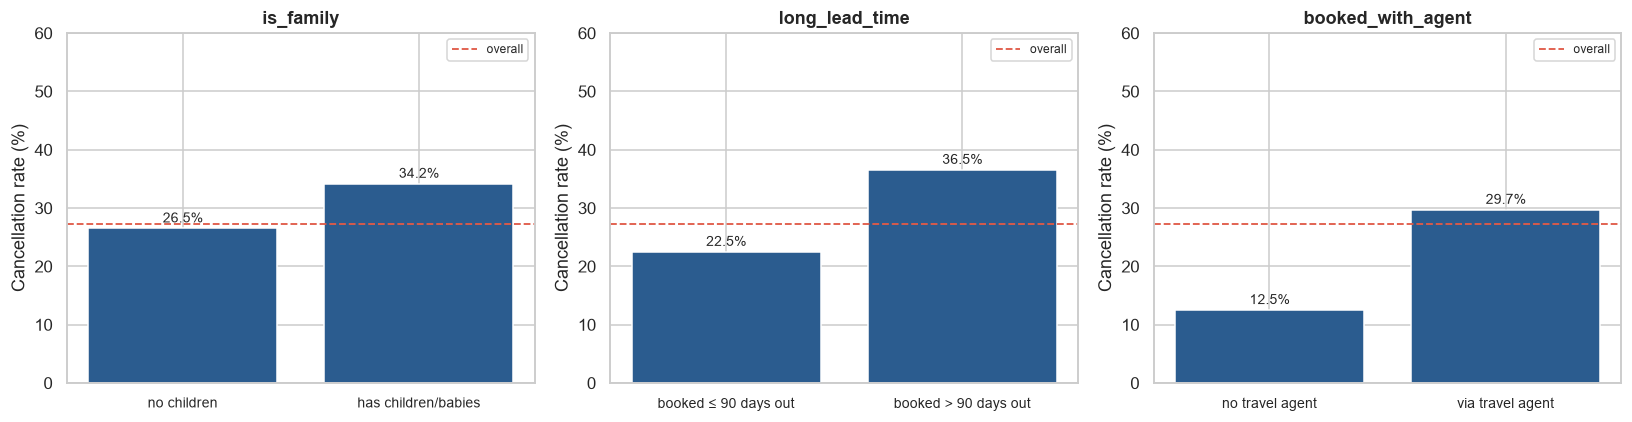

In [48]:
# Do the new booking-time features actually separate the classes?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, labels in [
    (axes[0], "is_family", ["no children", "has children/babies"]),
    (axes[1], "long_lead_time", ["booked ≤ 90 days out", "booked > 90 days out"]),
    (axes[2], "booked_with_agent", ["no travel agent", "via travel agent"]),
]:
    g = clean.groupby(col, observed=True)[TARGET].mean().mul(100)
    bars = ax.bar([0, 1], g.values, color=PRIMARY)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=9, padding=2)
    ax.axhline(clean[TARGET].mean() * 100, color=ACCENT, ls="--", lw=1.2, label="overall")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Cancellation rate (%)")
    ax.set_ylim(0, 60)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 11. The feature contract handed to notebook 02

This table is the frozen agreement. Notebook 02 reads it and never re-argues it: every member's model is
trained on exactly the columns marked `feature`, so the model comparison in the report is valid.

In [49]:
LEAKAGE_COLUMNS = ["reservation_status", "reservation_status_date"]          # already dropped
POST_BOOKING_COLUMNS = ["assigned_room_type", "booking_changes",
                        "days_in_waiting_list", "required_car_parking_spaces",
                        "room_changed"]
HELPER_COLUMNS = ["arrival_date"]        # kept for ordering/reporting, not a model input

def role_of(col):
    if col == TARGET:
        return "target"
    if col in POST_BOOKING_COLUMNS:
        return "post-booking"
    if col in HELPER_COLUMNS:
        return "helper"
    return "feature"

contract = pd.DataFrame({
    "dtype": clean.dtypes.astype(str),
    "n_unique": clean.nunique(),
    "role": [role_of(c) for c in clean.columns],
})
contract.index.name = "column"
contract = contract.sort_values(["role", "column"])
contract

,dtype,n_unique,role
column,,,
adr,float64,8864,feature
adr_per_guest,float64,10800,feature
adults,int64,14,feature
agent,str,334,feature
arrival_date_day_of_month,int64,31,feature
arrival_date_month,category,12,feature
arrival_date_week_number,int64,53,feature
arrival_date_year,int64,3,feature
arrival_season,str,4,feature


In [50]:
FEATURES = [c for c in clean.columns if role_of(c) == "feature"]
numeric_features = [c for c in FEATURES if pd.api.types.is_numeric_dtype(clean[c])]
categorical_features = [c for c in FEATURES if c not in numeric_features]

print(f"model features : {len(FEATURES)}")
print(f"  numeric      : {len(numeric_features)}  -> {numeric_features}")
print()
print(f"  categorical  : {len(categorical_features)}  -> {categorical_features}")
print()
print(f"excluded (leakage)      : {LEAKAGE_COLUMNS}")
print(f"excluded (post-booking) : {POST_BOOKING_COLUMNS}")

model features : 36
  numeric      : 24  -> ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'total_of_special_requests', 'booked_with_agent', 'booked_by_company', 'total_guests', 'total_nights', 'is_family', 'long_lead_time', 'total_previous_bookings', 'prev_cancel_ratio', 'has_previous_cancellation', 'adr_per_guest']

  categorical  : 12  -> ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type', 'lead_time_group', 'arrival_season']

excluded (leakage)      : ['reservation_status', 'reservation_status_date']
excluded (post-booking) : ['assigned_room_type', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'room_changed']


---
## 12. Save the cleaned dataset

In [51]:
OUT_CSV = PROCESSED_DIR / "hotel_bookings_clean.csv"
clean.to_csv(OUT_CSV, index=False)

contract.to_csv(REPORTS_DIR / "feature_roles.csv")
dictionary.to_csv(REPORTS_DIR / "data_dictionary.csv")

print("wrote:", OUT_CSV.relative_to(ROOT), f"({OUT_CSV.stat().st_size / 1e6:.1f} MB)")
print("wrote:", (REPORTS_DIR / 'feature_roles.csv').relative_to(ROOT))
print("wrote:", (REPORTS_DIR / 'data_dictionary.csv').relative_to(ROOT))
print()
print("shape:", clean.shape)
clean.head()

wrote: data\processed\hotel_bookings_clean.csv (14.9 MB)
wrote: reports\feature_roles.csv
wrote: reports\data_dictionary.csv

shape: (86965, 43)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,booked_with_agent,booked_by_company,total_guests,total_nights,is_family,lead_time_group,long_lead_time,arrival_date,arrival_season,total_previous_bookings,prev_cancel_ratio,has_previous_cancellation,adr_per_guest,room_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,...,0,0,Transient,0.0,0,0,0,0,2,0,0,181–365,1,2015-07-01,Summer,0,0.0,0,0.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,...,0,0,Transient,0.0,0,0,0,0,2,0,0,366+,1,2015-07-01,Summer,0,0.0,0,0.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,...,0,0,Transient,75.0,0,0,0,0,1,1,0,0–30,0,2015-07-01,Summer,0,0.0,0,75.0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,...,304,0,Transient,75.0,0,0,1,0,1,1,0,0–30,0,2015-07-01,Summer,0,0.0,0,75.0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,...,240,0,Transient,98.0,0,1,1,0,2,2,0,0–30,0,2015-07-01,Summer,0,0.0,0,49.0,0


In [52]:
# Guard rails — notebook 02 must not start if any of these fail.
assert clean.isna().sum().sum() == 0, "missing values survived cleaning"
assert clean.duplicated().sum() == 0, "duplicate rows survived cleaning"
assert not set(LEAKAGE_COLUMNS) & set(clean.columns), "a leakage column is still present"
assert set(clean[TARGET].unique()) == {0, 1}, "target is not binary"
assert clean["adr"].between(0, 1000).all(), "adr outside the cleaned range"
assert ((clean["adults"] + clean["children"] + clean["babies"]) > 0).all(), "zero-guest row survived"
assert len(FEATURES) > 20, "unexpectedly few features"
print("all guard rails passed")

all guard rails passed


---
## 13. Insight log

In [53]:
overall_raw = df[TARGET].mean()
overall_clean = clean[TARGET].mean()

log = f"""# EDA insight log — Hotel Booking Demand

Group 2026-AI-46 · IT3091 Machine Learning · owner M2 (Data & EDA)
Generated by `notebooks/01_eda_and_cleaning.ipynb`. Do not edit by hand — re-run the notebook.

## Dataset as loaded

| | |
| --- | --- |
| Rows | {len(df):,} |
| Columns | {len(RAW_COLUMNS)} |
| Period | July 2015 – August 2017 (2015 and 2017 are partial years) |
| Hotels | City Hotel ({int((df.hotel == 'City Hotel').sum()):,}), Resort Hotel ({int((df.hotel == 'Resort Hotel').sum()):,}) |
| Cancellation rate (business baseline) | {overall_raw:.2%} |
| Cancellation rate after cleaning (modelling baseline) | {overall_clean:.2%} |

## Data quality findings

| # | Finding | Evidence | Decision |
| --- | --- | --- | --- |
| 1 | `company` missing in 94.3% of rows | §5.1 | Not an unknown company — it means no company paid. Replaced by the `booked_by_company` flag; the ID is dropped. |
| 2 | `agent` missing in 13.7% of rows | §5.1 | Means the guest booked without an agent. Replaced by `booked_with_agent` plus an explicit `"0"` agent category. |
| 3 | `country` missing in 0.41% of rows | §5.1 | Genuinely unknown. Explicit `"Unknown"` category rather than mode-filling, which would invent Portuguese guests. |
| 4 | `children` missing in 4 rows | §5.1 | Filled with 0 (the value in 92.7% of rows). |
| 5 | 31,994 rows identical on all 32 columns; 32,252 identical once the two leakage columns are dropped | §5.2 | Removed, after the leakage columns, so the check sees exactly the columns a model will see. Probably genuine repeat bookings, but with no booking ID they let a classifier memorise across the train/test split. Cost: the measured cancellation rate falls from {overall_raw:.1%} to {overall_clean:.1%}. |
| 6 | 180 bookings with zero guests | §5.3 | Removed — a booking with nobody on it cannot be honoured or cancelled meaningfully. |
| 7 | `adr` = −6.38 and `adr` = 5400 (next highest 510) | §5.3 | Both removed as demonstrable data-entry errors. The 1,959 `adr = 0` rows are kept — they are complimentary/staff/group rates. |
| 8 | 1.5×IQR flags thousands of `lead_time` values | §5.4 | No blanket outlier removal — long lead times are real and carry the strongest signal. Heavy tails handled by scaling inside the pipeline. |
| 9 | `meal = "Undefined"` (1,169 rows) | §5.3 | Merged into `SC`; the dataset authors document them as the same thing. |

## Leakage findings

| # | Finding | Evidence | Decision |
| --- | --- | --- | --- |
| L1 | `reservation_status` maps perfectly onto the target | §7.1 | Dropped permanently, with `reservation_status_date`. |
| L2 | 7,416 bookings request parking; **0** were ever cancelled | §7.3 | `required_car_parking_spaces` is populated at check-in. Moved to the post-booking exclusion list. |
| L3 | `room_changed` (reserved ≠ assigned) is strongly *anti*-correlated with cancelling | §8.10 | A room is only re-assigned to a guest who arrived. Post-booking; excluded. |
| L4 | 99.4% of `Non Refund` bookings are cancelled | §7.4 | **Not** leakage — deposit type is fixed at booking. Kept as a feature, with the caveat that the model partly learns the hotel's own historical risk policy. |

## Cancellation drivers (raw data, {overall_raw:.1%} overall)

| Driver | Lowest-risk group | Highest-risk group | Evidence |
| --- | --- | --- | --- |
| Deposit type | Refundable 22.2% | Non Refund 99.4% | §7.4 |
| Previous cancellations | none 33.9% | at least one 91.6% | §8.5 |
| Market segment | Direct 15.3% | Groups 61.1% | §8.4 |
| Lead time | 0–30 days 18.6% | 366+ days 67.7% | §8.2 |
| Special requests | four or more 10.6% | none 47.7% | §8.6 |
| Hotel | Resort 27.8% | City 41.7% | §8.1 |
| Country (top 10) | international, mostly below average | Portugal 56.6% | §8.8 |
| Season | flat — no clean annual cycle | | §8.7 |

## Consequences for modelling

1. Accuracy is unusable on its own: predicting "never cancels" scores {1 - overall_clean:.1%} on the cleaned data. Primary metrics are PR-AUC, F1 and recall on the cancelled class.
2. No numeric column correlates with the target above |0.29|, and the strongest drivers are categorical — so a linear baseline is expected to be beaten by tree ensembles. That comparison is the point of the study, not an assumption.
3. `country` (177 levels) needs a leakage-safe encoding fitted inside the CV folds, not a plain one-hot.
4. Class imbalance is mild ({overall_clean:.1%} positive), so stratification + class weights + threshold tuning; no SMOTE.
5. 2015 and 2017 are partial years, so `arrival_date_year` must not be read as a trend.

## Handover to notebook 02

| | |
| --- | --- |
| File | `data/processed/hotel_bookings_clean.csv` |
| Rows × columns | {clean.shape[0]:,} × {clean.shape[1]} |
| Model features | {len(FEATURES)} ({len(numeric_features)} numeric, {len(categorical_features)} categorical) |
| Target | `is_canceled` ({overall_clean:.2%} positive) |
| Excluded — leakage | {', '.join('`' + c + '`' for c in LEAKAGE_COLUMNS)} |
| Excluded — post-booking | {', '.join('`' + c + '`' for c in POST_BOOKING_COLUMNS)} |
| Random seed | {RANDOM_SEED} |
"""

log_path = REPORTS_DIR / "eda_insight_log.md"
log_path.write_text(log, encoding="utf-8")
print("wrote:", log_path.relative_to(ROOT), f"({len(log):,} characters)")

wrote: reports\eda_insight_log.md (4,838 characters)


---
## 14. Where this leaves us

**Done in this notebook (Week 2 of the plan).** Data understood and documented, quality problems found
and decided with evidence, three leakage traps caught, ~20 EDA charts read, the cleaned table and the
feature contract written to disk.

**Next, in `notebooks/02_pipeline_and_split.ipynb` (Week 3, M3 leads, M4 sets up the metric harness).**

1. Load `hotel_bookings_clean.csv` and the `feature_roles.csv` contract.
2. Stratified train/test split, `random_state=42`, held out before any model selection.
3. One `ColumnTransformer` — median imputation and scaling for the numeric block, one-hot for the
   low-cardinality categoricals, a leakage-safe encoder for `country` and `agent` — fitted **inside** the
   folds only.
4. Freeze the CV fold definition and the metric harness (PR-AUC, F1, recall, ROC-AUC, calibration).
5. From Week 4 each member trains their own model on this identical foundation, which is what makes the
   final comparison table in the report a fair one.